# GRAPH CONVOLUTIONAL NEURAL NETWORK

## PARAMETER CONFIGURATION

In [1]:
batch_size = 8
#Splitting the dataset manually
train_files = [
    # FP11
    {"label": [0], "topology_filename": "../FP11/SYSTEMns.prmtop", "coordinates_filename": "../FP11/PRODUCTION_3/TRAJ-150ns.nc"},
    {"label": [0], "topology_filename": "../FP11/SYSTEMns.prmtop", "coordinates_filename": "../FP11/PRODUCTION_4/TRAJ-150ns.nc"},
    {"label": [0], "topology_filename": "../FP11/SYSTEMns.prmtop", "coordinates_filename": "../FP11/PRODUCTION_5/TRAJ-150ns.nc"},
    {"label": [0], "topology_filename": "../FP11/SYSTEMns.prmtop", "coordinates_filename": "../FP11/PRODUCTION_6/TRAJ-150ns.nc"},
    #{"label": [0], "topology_filename": "../FP11/SYSTEMns.prmtop", "coordinates_filename": "../FP11/PRODUCTION_7/TRAJ-76-150ns.nc"},
    # FP12
    {"label": [1], "topology_filename": "../FP12/SYSTEMns.prmtop", "coordinates_filename": "../FP12/PRODUCTION_3/TRAJ-150ns.nc"},
    {"label": [1], "topology_filename": "../FP12/SYSTEMns.prmtop", "coordinates_filename": "../FP12/PRODUCTION_4/TRAJ-150ns.nc"},
    {"label": [1], "topology_filename": "../FP12/SYSTEMns.prmtop", "coordinates_filename": "../FP12/PRODUCTION_5/TRAJ-150ns.nc"},
    {"label": [1], "topology_filename": "../FP12/SYSTEMns.prmtop", "coordinates_filename": "../FP12/PRODUCTION_6/TRAJ-150ns.nc"},
    #{"label": [1], "topology_filename": "../FP12/SYSTEMns.prmtop", "coordinates_filename": "../FP12/PRODUCTION_7/TRAJ-76-150ns.nc"}
]

test_files = [
    # FP11
    #{"label": [0], "topology_filename": "../FP11/SYSTEMns.prmtop", "coordinates_filename": "../FP11/PRODUCTION_3/TRAJ-76-150ns.nc"},
    #{"label": [0], "topology_filename": "../FP11/SYSTEMns.prmtop", "coordinates_filename": "../FP11/PRODUCTION_4/TRAJ-76-150ns.nc"},
    #{"label": [0], "topology_filename": "../FP11/SYSTEMns.prmtop", "coordinates_filename": "../FP11/PRODUCTION_5/TRAJ-76-150ns.nc"},
    #{"label": [0], "topology_filename": "../FP11/SYSTEMns.prmtop", "coordinates_filename": "../FP11/PRODUCTION_6/TRAJ-76-150ns.nc"},
    {"label": [0], "topology_filename": "../FP11/SYSTEMns.prmtop", "coordinates_filename": "../FP11/PRODUCTION_7/TRAJ-150ns.nc"},
    # FP12
    #{"label": [1], "topology_filename": "../FP12/SYSTEMns.prmtop", "coordinates_filename": "../FP12/PRODUCTION_3/TRAJ-76-150ns.nc"},
    #{"label": [1], "topology_filename": "../FP12/SYSTEMns.prmtop", "coordinates_filename": "../FP12/PRODUCTION_4/TRAJ-76-150ns.nc"},
    #{"label": [1], "topology_filename": "../FP12/SYSTEMns.prmtop", "coordinates_filename": "../FP12/PRODUCTION_5/TRAJ-76-150ns.nc"},
    #{"label": [1], "topology_filename": "../FP12/SYSTEMns.prmtop", "coordinates_filename": "../FP12/PRODUCTION_6/TRAJ-76-150ns.nc"},
    {"label": [1], "topology_filename": "../FP12/SYSTEMns.prmtop", "coordinates_filename": "../FP12/PRODUCTION_7/TRAJ-150ns.nc"}
]
#####

selection_string = "resid 247 618 626 627 628 638 640 642 646 655 657 659 661 665 670 672 674 675 684 686 688 696 698 707 709 711 712 713 714 715716 717 718 725 726 727 729 740 741 743 745 746 747 " #Full-atom of avtive region of MD2
epochs = 200
lr = 0.0001
test_size = 0.20
random_state = 42

In [2]:
train_files

[{'label': [0],
  'topology_filename': '../FP11/SYSTEMns.prmtop',
  'coordinates_filename': '../FP11/PRODUCTION_3/TRAJ-150ns.nc'},
 {'label': [0],
  'topology_filename': '../FP11/SYSTEMns.prmtop',
  'coordinates_filename': '../FP11/PRODUCTION_4/TRAJ-150ns.nc'},
 {'label': [0],
  'topology_filename': '../FP11/SYSTEMns.prmtop',
  'coordinates_filename': '../FP11/PRODUCTION_5/TRAJ-150ns.nc'},
 {'label': [0],
  'topology_filename': '../FP11/SYSTEMns.prmtop',
  'coordinates_filename': '../FP11/PRODUCTION_6/TRAJ-150ns.nc'},
 {'label': [1],
  'topology_filename': '../FP12/SYSTEMns.prmtop',
  'coordinates_filename': '../FP12/PRODUCTION_3/TRAJ-150ns.nc'},
 {'label': [1],
  'topology_filename': '../FP12/SYSTEMns.prmtop',
  'coordinates_filename': '../FP12/PRODUCTION_4/TRAJ-150ns.nc'},
 {'label': [1],
  'topology_filename': '../FP12/SYSTEMns.prmtop',
  'coordinates_filename': '../FP12/PRODUCTION_5/TRAJ-150ns.nc'},
 {'label': [1],
  'topology_filename': '../FP12/SYSTEMns.prmtop',
  'coordinates_fi

In [3]:
test_files

[{'label': [0],
  'topology_filename': '../FP11/SYSTEMns.prmtop',
  'coordinates_filename': '../FP11/PRODUCTION_7/TRAJ-150ns.nc'},
 {'label': [1],
  'topology_filename': '../FP12/SYSTEMns.prmtop',
  'coordinates_filename': '../FP12/PRODUCTION_7/TRAJ-150ns.nc'}]

In [4]:
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

from torch.nn import Embedding, CrossEntropyLoss, Linear, ReLU
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, AttentionalAggregation
from torch_geometric.nn import radius_graph
from torch_geometric.utils import scatter
from sklearn.model_selection import train_test_split

import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tqdm
import json

/usr/local/jupyter-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
torch.cuda.is_available()

True

## DATA LOAD

In [6]:
# u = mda.Universe("../data/md-2025-03-11/FP11ns.prmtop", "../data/md-2025-03-11/FP11-150ns.nc")
# residue_index = dict((key, id) for id, key in enumerate(np.unique(u.select_atoms('name CA').resnames).tolist()))
# atom_type_index = dict((key, id) for id, key in enumerate(np.unique(u.select_atoms('protein').atoms.types.tolist())))

with open('atom-list.json') as f: 
    atom_type_index = json.load(f)
with open('residue-list.json') as f: 
    residue_index = json.load(f)

In [7]:
def trajectory_to_data(u, selection_string, residue_index, atom_type_index, label):
    for fr in u.trajectory:
        x = torch.from_numpy(u.select_atoms(selection_string).positions)
        residues = list(map(lambda x: residue_index[x], u.select_atoms(selection_string).resnames))
        atom_types = list(map(lambda x: atom_type_index[x], u.select_atoms(selection_string).atoms.types.tolist()))
        d = Data(pos=x, res=torch.tensor(residues, dtype=torch.long), types=torch.tensor(atom_types, dtype=torch.long), label=torch.tensor(label, dtype=torch.long))
        yield d

### Manual Data Splitting

In [8]:
train_trj = []

for file in train_files:

    u = mda.Universe(file['topology_filename'], file['coordinates_filename'])
    train_trj += list(trajectory_to_data(u, selection_string, residue_index, atom_type_index, file['label']))
    print(file['coordinates_filename']) # to check all files are read correctly
    print(len(u.trajectory)) # to check there are 750 frames per file
    
train_trj[:5]

../FP11/PRODUCTION_3/TRAJ-150ns.nc
15000
../FP11/PRODUCTION_4/TRAJ-150ns.nc
15000
../FP11/PRODUCTION_5/TRAJ-150ns.nc
15000
../FP11/PRODUCTION_6/TRAJ-150ns.nc
15000
../FP12/PRODUCTION_3/TRAJ-150ns.nc
15000
../FP12/PRODUCTION_4/TRAJ-150ns.nc
15000
../FP12/PRODUCTION_5/TRAJ-150ns.nc
15000
../FP12/PRODUCTION_6/TRAJ-150ns.nc
15000


[Data(pos=[727, 3], res=[727], types=[727], label=[1]),
 Data(pos=[727, 3], res=[727], types=[727], label=[1]),
 Data(pos=[727, 3], res=[727], types=[727], label=[1]),
 Data(pos=[727, 3], res=[727], types=[727], label=[1]),
 Data(pos=[727, 3], res=[727], types=[727], label=[1])]

In [9]:
len(train_trj)

120000

In [10]:
test_trj = []

for file in test_files:

    u = mda.Universe(file['topology_filename'], file['coordinates_filename'])
    test_trj += list(trajectory_to_data(u, selection_string, residue_index, atom_type_index, file['label']))
    print(file['coordinates_filename']) # to check all files are read correctly
    print(len(u.trajectory)) # to check there are 750 frames per file
    
test_trj[:5]

../FP11/PRODUCTION_7/TRAJ-150ns.nc
15000
../FP12/PRODUCTION_7/TRAJ-150ns.nc
15000


[Data(pos=[727, 3], res=[727], types=[727], label=[1]),
 Data(pos=[727, 3], res=[727], types=[727], label=[1]),
 Data(pos=[727, 3], res=[727], types=[727], label=[1]),
 Data(pos=[727, 3], res=[727], types=[727], label=[1]),
 Data(pos=[727, 3], res=[727], types=[727], label=[1])]

In [11]:
len(test_trj)

30000

## GRAPH MANIPULATION

In [12]:
import networkx as nx
train_trj[20]
edges = radius_graph(train_trj[20].pos, r=1.5)
G = nx.Graph()
G.add_edges_from(edges.T.tolist())

In [13]:
len(list(nx.connected_components(G)))

179

## MODEL

In [14]:
class GCN(torch.nn.Module):
    def __init__(self, radius):
        super().__init__()
        self.radius = radius
        self.embed_res = Embedding(num_embeddings=24, embedding_dim=128)
        self.embed_type = Embedding(num_embeddings=33, embedding_dim=128)
        # RESDIUE TYPE BRANCH
        self.conv1_res = GCNConv(128, 64)
        self.relu1_res = ReLU()
        self.conv2_res = GCNConv(64, 32)
        self.relu2_res = ReLU()
        self.conv3_res = GCNConv(32, 16)
        # ATOM TYPE BRANCH
        self.conv1_type = GCNConv(128, 64)
        self.relu1_type = ReLU()
        self.conv2_type = GCNConv(64, 32)
        self.relu2_type = ReLU()
        self.conv3_type = GCNConv(32, 16)
        # ATTENTION MECHANISM IN POOLING LAYER
        self.pool_res = AttentionalAggregation(gate_nn=torch.nn.Sequential(Linear(16,1),ReLU(),Linear(1,1)))
        self.pool_type = AttentionalAggregation(gate_nn=torch.nn.Sequential(Linear(16,1),ReLU(),Linear(1,1)))
        # LINEAR LAYER
        self.linear1 = Linear(32, 2)

    def forward(self, data):
        pos, res, type, batch = data.pos, data.res, data.types, data.batch
        edge_index = radius_graph(pos, r=self.radius, batch=batch)
        # FORWARD PASS OF RESIDUES TYPES
        z_res = self.embed_res(res)
        z_res = self.conv1_res(z_res, edge_index)
        z_res = self.relu1_res(z_res)
        z_res = self.conv2_res(z_res, edge_index)
        z_res = self.relu2_res(z_res)
        z_res = self.conv3_res(z_res, edge_index)
        # FORWARD PASS OF ATOMS TYPES
        z_type = self.embed_type(type)
        z_type = self.conv1_type(z_type, edge_index)
        z_type = self.relu1_type(z_type)
        z_type = self.conv2_type(z_type, edge_index)
        z_type = self.relu2_type(z_type)
        z_type = self.conv3_type(z_type, edge_index)
        #
        #z_res = scatter(z_res, data.batch, dim=0, reduce='mean')
        #z_type = scatter(z_type, data.batch, dim=0, reduce='mean')
        # FORWARD PASS POOLING AND LINEAR LAYER
        z_res = self.pool_res(z_res, data.batch)
        z_type = self.pool_type(z_type, data.batch)
        z = torch.cat([z_res, z_type], dim=1)
        z = self.linear1(z)
        #z = F.softmax(z, dim=1) #CrossEntropyLoss already does softmax at the end
        return z

In [15]:
#train_trj, test_trj = train_test_split(trj, test_size=test_size, random_state=random_state)

In [16]:
#!pip install networkx
#import networkx as nx
#train_trj[0]
#edges = radius_graph(train_trj[0].pos, r=5.0)
#G = nx.Graph()
#G.add_edges_from(edges.T.tolist())
#len(list(nx.connected_components(G)))
#nx.write_graphml(G, "foo.graphml")
#!nvidia-smi

## VALIDATION

In [17]:
gcn = GCN(radius=4.0).to(torch.device("cuda:0"))
loss = CrossEntropyLoss()
optimizer = torch.optim.Adam(gcn.parameters(), lr=lr, weight_decay=5e-4)
train_loader = DataLoader(train_trj, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_trj, batch_size=batch_size, shuffle=True)
history = []
for i in tqdm.tqdm(range(epochs)):
    statistics = dict()
    statistics['training_loss'] = 0.0
    gcn.train()
    for d in train_loader:
        d = d.to(torch.device("cuda:0"))
        optimizer.zero_grad()
        z = gcn(d)
        l = loss(z, d.label)
        l.backward()
        optimizer.step()
    statistics['training_loss'] += l.item()
    gcn.eval()
    with torch.no_grad():
        statistics['test_accuracy'] = 0.0
        statistics['test_loss'] = 0.0
        for d in test_loader:
            d = d.to(torch.device("cuda:0"))
            z = gcn(d)
            l = loss(z, d.label)
            a = ((z.argmax(1) == d.label).sum())
            statistics['test_accuracy'] += a.item()
            statistics['test_loss'] += l.item()
                
    statistics['test_accuracy'] /= len(test_trj)
    statistics['test_loss'] /= ((len(test_trj) // batch_size) + 1)

    print(f"Epoch {i+1:2d} | Accuracy {statistics['test_accuracy']:.4f}")
    history.append(statistics)

  0%|▊                                                                                                                                                                  | 1/200 [05:03<16:46:31, 303.47s/it]

Epoch  1 | Accuracy 0.5358


  1%|█▋                                                                                                                                                                 | 2/200 [10:01<16:31:00, 300.31s/it]

Epoch  2 | Accuracy 0.5782


  2%|██▍                                                                                                                                                                | 3/200 [14:58<16:20:47, 298.72s/it]

...

Epoch 198 | Accuracy 0.7193


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏| 199/200 [16:31:37<04:57, 297.56s/it]

Epoch 199 | Accuracy 0.6556


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [16:36:34<00:00, 298.97s/it]

Epoch 200 | Accuracy 0.6571


In [18]:
pd.DataFrame.from_records(history)

,training_loss,test_accuracy,test_loss
0,0.661681,0.535800,0.746815
1,0.328928,0.578167,0.742026
2,0.759342,0.622667,0.781094
3,0.292993,0.681333,0.630020
4,0.349854,0.723433,0.677082
...,...,...,...
195,0.133051,0.742233,0.675822
196,0.041336,0.754533,0.677183
197,0.309899,0.719333,0.713800
198,0.376932,0.655600,1.126960


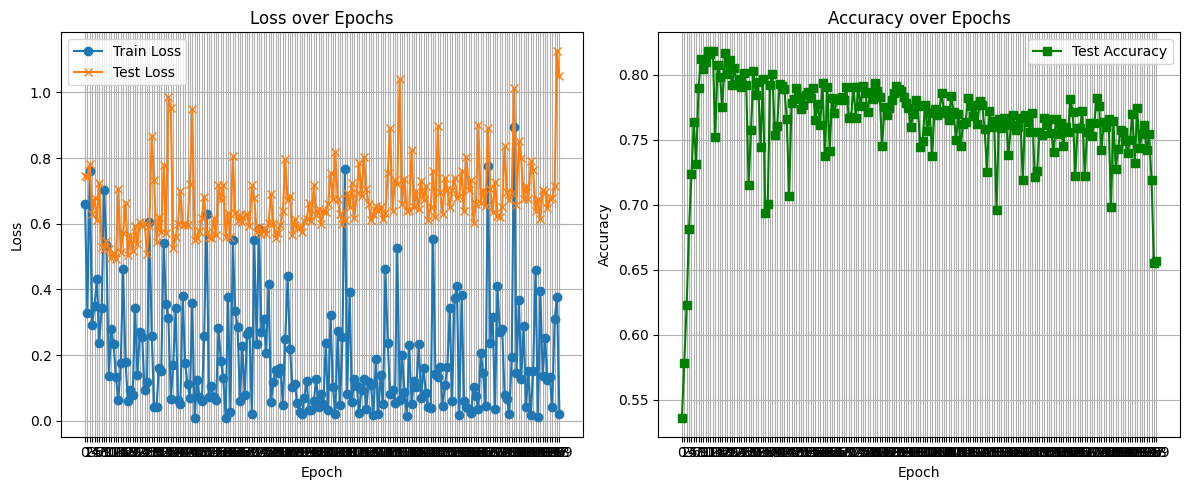

In [19]:
# Plotting the results
train_loss = [h['training_loss'] for h in history]
test_loss = [h['test_loss'] for h in history]
test_accuracy = [h['test_accuracy'] for h in history]
epochs_count = list(range(0, len(history)))
#epochs_count = list(range(0,20))
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_loss, label='Train Loss', marker='o')
plt.plot(test_loss, label='Test Loss', marker='x')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(epochs_count)
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(test_accuracy, label='Test Accuracy', marker='s', color='green')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xticks(epochs_count)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()